In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lsst.daf.butler import Butler
import polars
from tqdm import tqdm
import lsst.geom as geom
import pandas as pd

In [25]:
repo = "dp2_prep"
collection = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"

PARQUET_COLUMNS = [
    'slot_Centroid_x', 'slot_Centroid_y', 'detector', 'psf_max_value',
]

butler = Butler(repo, collections=collection)

In [33]:
def getStarImage(visit, detector, stampSize = 41):

#stampSize = 41
#visit = 2025050400608
#detector = 42
    
    dataID = {
        "instrument": "LSSTCam", 
        "visit": visit,
        "detector": detector,
    }
    uri = butler.getURI("refit_psf_star", **dataID)
    parquet_path = uri.geturl()
    psfTable = polars.scan_parquet(parquet_path).select(PARQUET_COLUMNS).collect()
    psfTable = psfTable.filter(polars.col("detector") == detector)
    
    calexp = butler.get("preliminary_visit_image", **dataID)
    try: 
        plt.figure(figsize=(8,8))
        plt.subplots_adjust(wspace=0.)
        stars = []
        weights = [] 
        for i in tqdm(range(len(psfTable['slot_Centroid_x']))):
                if psfTable['psf_max_value'][i] > 10000 and psfTable['psf_max_value'][i]< 40000:
                    positionStar = geom.Point2D(psfTable['slot_Centroid_x'][i], psfTable['slot_Centroid_y'][i])
                    srcImg = calexp.getCutout(positionStar, geom.Extent2I(stampSize, stampSize))
                    im = srcImg.getMaskedImage()
                    star = im.image.array / np.sum(im.image.array)
                    var = im.variance.array / np.sum(im.image.array)
                    stars.append(star)
                    weights.append(1. / var)
        
        stars = np.array(stars)
        weights = np.array(weights)
        meanStar = np.average(stars, weights=weights, axis=0)
        
        plt.figure(figsize=(5,5))
        plt.imshow(star, cmap=plt.cm.Greys_r, vmin=0, vmax=np.max(meanStar))
        plt.gca().invert_yaxis()
        plt.xticks([],[])
        plt.yticks([],[])
        plt.title(f"{visit} | {detector}")
    except:
        print('failed')

In [31]:
badVisitDic = pd.read_pickle('data/badDetectorList.pkl')

100%|██████████| 21/21 [00:00<00:00, 278735.39it/s]


failed


100%|██████████| 29/29 [00:00<00:00, 334161.58it/s]


failed


100%|██████████| 33/33 [00:00<00:00, 377144.50it/s]


...

failed


100%|██████████| 22/22 [00:00<00:00, 272196.72it/s]


failed


100%|██████████| 30/30 [00:00<00:00, 63198.96it/s]


<Figure size 800x800 with 0 Axes>

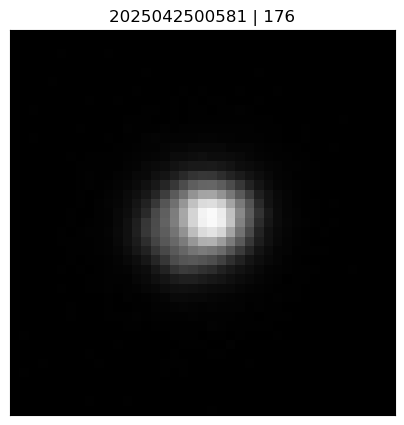

<Figure size 800x800 with 0 Axes>

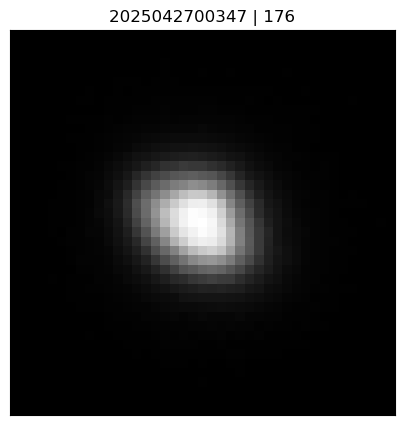

<Figure size 800x800 with 0 Axes>

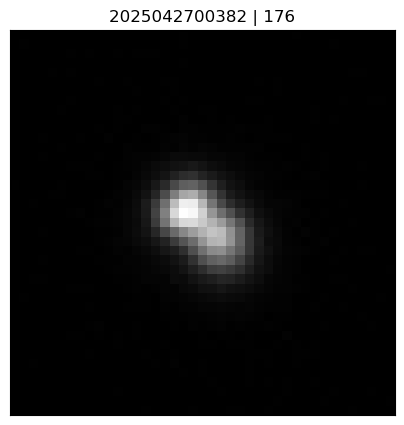

<Figure size 800x800 with 0 Axes>

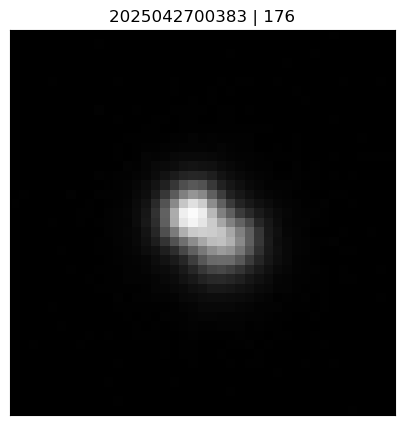

<Figure size 800x800 with 0 Axes>

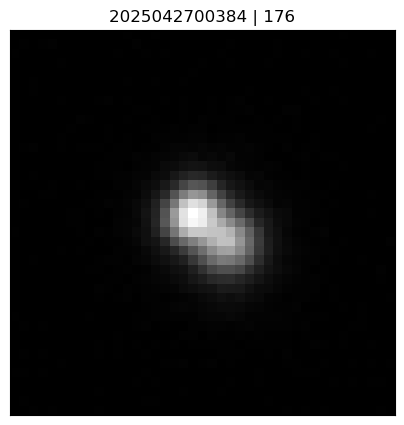

<Figure size 800x800 with 0 Axes>

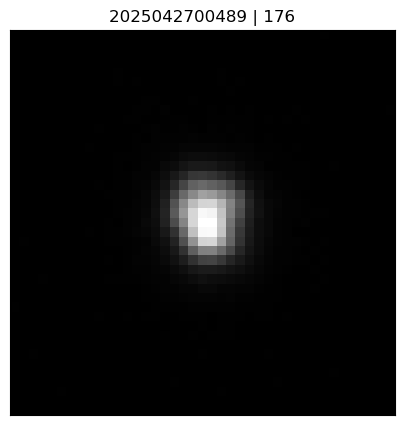

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

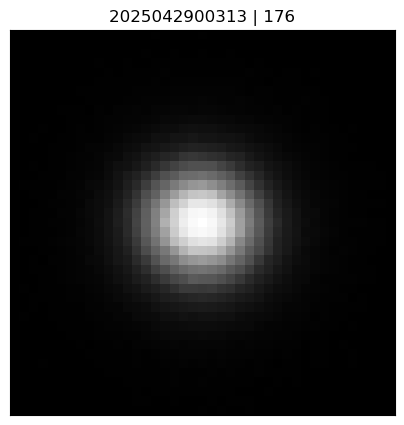

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

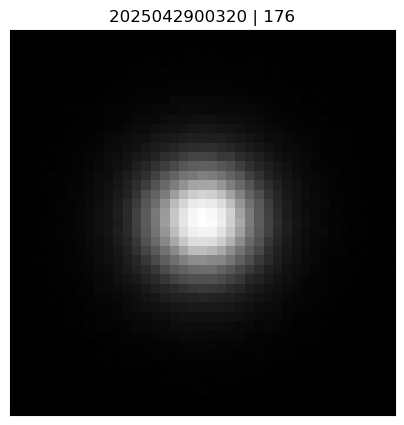

<Figure size 800x800 with 0 Axes>

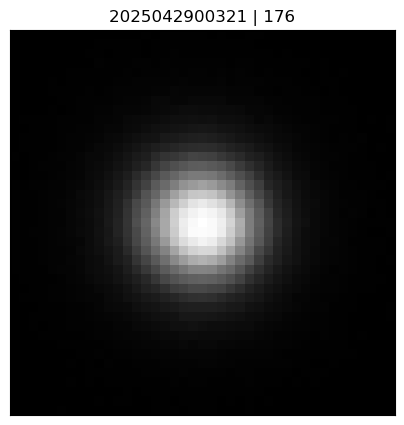

<Figure size 800x800 with 0 Axes>

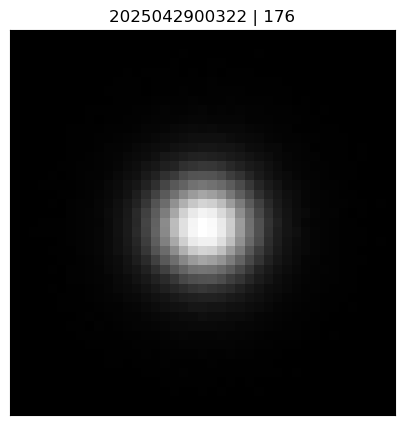

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

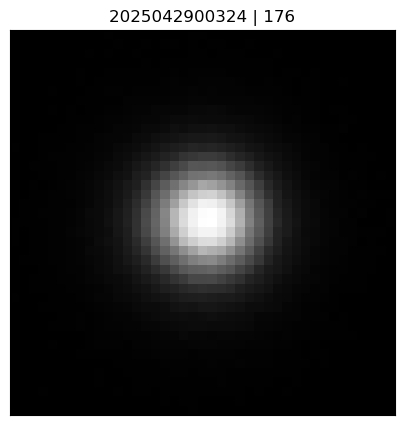

<Figure size 800x800 with 0 Axes>

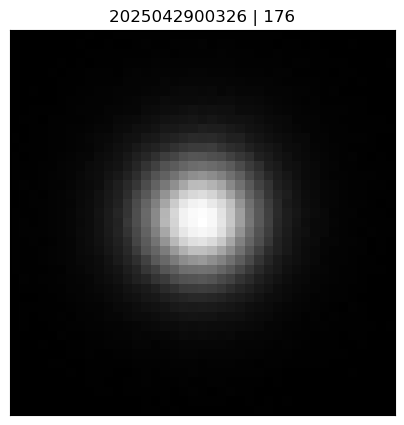

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

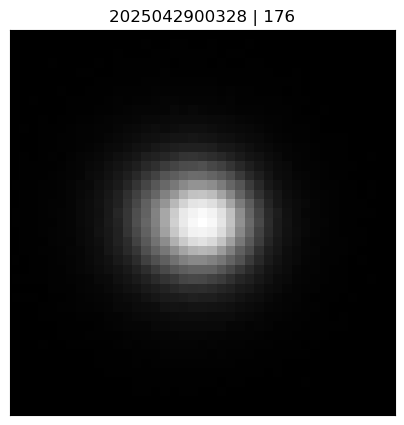

<Figure size 800x800 with 0 Axes>

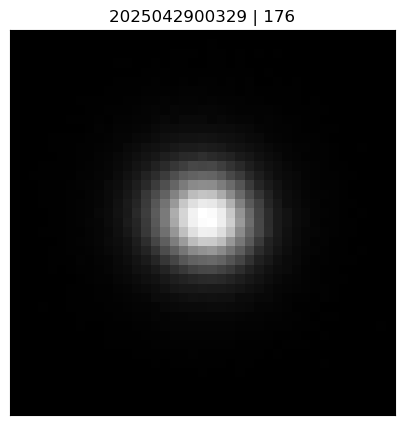

<Figure size 800x800 with 0 Axes>

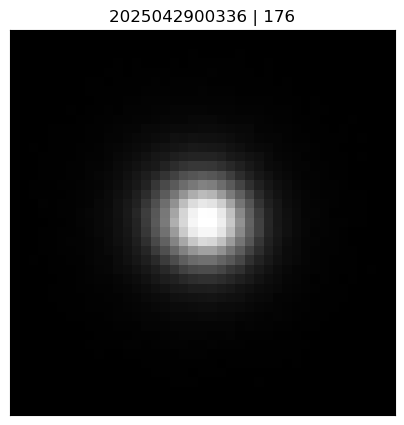

<Figure size 800x800 with 0 Axes>

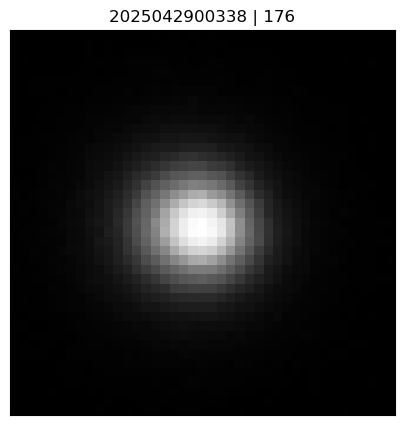

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

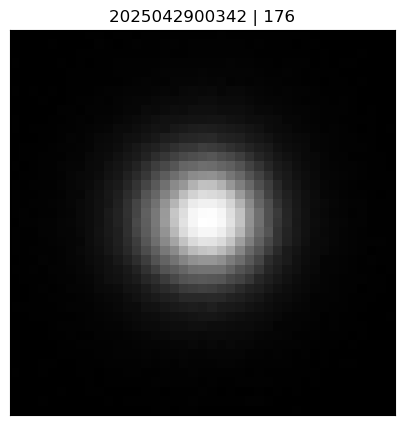

In [34]:
N_bad = 0 

for visit in badVisitDic:

    isRejected = np.array([badVisitDic[visit][det] for det in badVisitDic[visit]])
    ratioKept = np.sum(~isRejected)/len(isRejected)
    if ratioKept < 0.1:
        nbaddetector = 0
        for det in badVisitDic[visit]:
            if badVisitDic[visit][det] == True:
                getStarImage(visit, 176, stampSize = 41)
                nbaddetector += 1
            if nbaddetector == 1: 
                break
        N_bad += 1
    if N_bad > 25:
        break

In [ ]:
plt.su